# Task 5: Auto-Tagging Support Tickets Using LLM

**Objective:** Automatically tag support tickets into categories using a Large Language Model (LLM) through prompt engineering, comparing zero-shot vs few-shot performance.

**Dataset:** Free-text Support Ticket Dataset (generated synthetically)

**Tools:** `transformers`, `pandas`, `scikit-learn`, `matplotlib`, `seaborn`

**Approach:**
- LLM: `google/flan-t5-base` (local, no API key needed)
- Zero-shot prompting: ask the model to tag with no examples
- Few-shot prompting: provide 2-3 examples before asking
- Output: Top 3 most probable tags per ticket

## 1. Install Dependencies


In [1]:
!pip install -q transformers torch pandas scikit-learn matplotlib seaborn

## 2. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import warnings
warnings.filterwarnings("ignore")
from transformers import pipeline

print("All imports successful")
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

All imports successful
Device: cuda


## 3. Define Support Ticket Categories

The model will assign tickets to one or more of these categories:
- **Billing** — payment, invoice, subscription issues
- **Technical** — bugs, errors, crashes, performance
- **Account** — login, password, access issues
- **Shipping** — delivery, tracking, logistics
- **Refund** — returns, cancellations, refund requests
- **General** — other inquiries

In [3]:
CATEGORIES = ["Billing", "Technical", "Account", "Shipping", "Refund", "General"]
print("Categories:", CATEGORIES)

Categories: ['Billing', 'Technical', 'Account', 'Shipping', 'Refund', 'General']


## 4. Create Support Ticket Dataset

We create a realistic synthetic dataset of 30 support tickets across all 6 categories.

In [4]:
tickets_data = {
    "ticket_id": list(range(1, 31)),
    "ticket_text": [
        # Billing
        "I was charged twice for my subscription this month. Please refund the extra charge.",
        "My invoice shows an incorrect amount. I should have been charged $29 not $59.",
        "I cannot find my billing history. Where can I download my past invoices?",
        "Why was my credit card charged after I cancelled my plan?",
        "I need a receipt for my purchase made on June 15th for tax purposes.",
        # Technical
        "The app keeps crashing whenever I try to upload a file larger than 10MB.",
        "I am getting a 500 internal server error when I try to login from mobile.",
        "The dashboard is extremely slow and takes over 30 seconds to load.",
        "My data export is not working. The download button does nothing when clicked.",
        "I found a bug where the search results show duplicate entries.",
        # Account
        "I forgot my password and the reset email is not arriving in my inbox.",
        "I cannot login to my account. It says my email is not recognized.",
        "Please help me change the email address associated with my account.",
        "I need to transfer my account to a different organization.",
        "My account was locked after too many failed login attempts. Please unlock it.",
        # Shipping
        "My order was supposed to arrive 5 days ago but I have not received it yet.",
        "The tracking number you provided does not work on the courier website.",
        "I received the wrong item in my delivery. I ordered a blue one not red.",
        "Can I change my delivery address after the order has been placed?",
        "My package shows as delivered but I never received it.",
        # Refund
        "I want to cancel my order and get a full refund immediately.",
        "I returned the product 2 weeks ago but have not received my refund yet.",
        "The product I received was damaged. I want a replacement or refund.",
        "I cancelled my subscription but was still charged. Please refund me.",
        "How long does a refund take to appear on my credit card statement?",
        # General
        "Can you tell me what features are included in the premium plan?",
        "Do you offer discounts for non-profit organizations?",
        "What are your customer support hours?",
        "Is there a mobile app available for Android?",
        "How do I export my data if I decide to close my account?"
    ],
    "true_label": (
        ["Billing"] * 5 +
        ["Technical"] * 5 +
        ["Account"] * 5 +
        ["Shipping"] * 5 +
        ["Refund"] * 5 +
        ["General"] * 5
    )
}

df = pd.DataFrame(tickets_data)
print(f"Dataset shape: {df.shape}")
print(f"\nCategory distribution:\n{df['true_label'].value_counts()}")
df.head(10)

Dataset shape: (30, 3)

Category distribution:
true_label
Billing      5
Technical    5
Account      5
Shipping     5
Refund       5
General      5
Name: count, dtype: int64


,ticket_id,ticket_text,true_label
0,1,I was charged twice for my subscription this m...,Billing
1,2,My invoice shows an incorrect amount. I should...,Billing
2,3,I cannot find my billing history. Where can I ...,Billing
3,4,Why was my credit card charged after I cancell...,Billing
4,5,I need a receipt for my purchase made on June ...,Billing
5,6,The app keeps crashing whenever I try to uploa...,Technical
6,7,I am getting a 500 internal server error when ...,Technical
7,8,The dashboard is extremely slow and takes over...,Technical
8,9,My data export is not working. The download bu...,Technical
9,10,I found a bug where the search results show du...,Technical


## 5. Load LLM (Flan-T5-Base)

In [6]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

print("Loading flan-t5-base model...")

model_name = "google/flan-t5-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

def generate_answer(prompt, max_new_tokens=50):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device)
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True).strip()

print("Model loaded successfully")

# Test it
test = generate_answer("What is machine learning? Answer in one sentence.")
print("Test output:", test)

Loading flan-t5-base model...


tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Model loaded successfully
Test output: Machine learning is a technology that uses computer algorithms to learn information.


## 6. Zero-Shot Tagging

In zero-shot prompting, we ask the model to classify the ticket with no examples provided. We simply describe the task and provide the category options.

In [7]:
def zero_shot_tag(ticket_text, categories=CATEGORIES):
    categories_str = ", ".join(categories)
    prompt = f"""Classify this support ticket into one of these categories: {categories_str}.

Support ticket: {ticket_text}

Answer with only the category name."""

    result = generate_answer(prompt)

    for cat in categories:
        if cat.lower() in result.lower():
            return cat
    return result


## 7. Few-Shot Tagging

In few-shot prompting, we provide 2 labeled examples before asking the model to classify. This guides the model toward the expected output format and improves accuracy.

In [10]:
FEW_SHOT_EXAMPLES = """Examples:
Ticket: "I was charged twice for my subscription." -> Billing
Ticket: "The app crashes when I upload files." -> Technical
Ticket: "I forgot my password and cannot login." -> Account
Ticket: "My order has not arrived after 7 days." -> Shipping
Ticket: "I returned the product but got no refund." -> Refund
Ticket: "What features does the premium plan include?" -> General"""

def few_shot_tag(ticket_text, categories=CATEGORIES):
    """Tag a support ticket using few-shot prompting."""
    categories_str = ", ".join(categories)
    prompt = f"""Classify support tickets into one of these categories: {categories_str}.

{FEW_SHOT_EXAMPLES}

Now classify this ticket:
Ticket: "{ticket_text}" ->"""

    result = generate_answer(prompt)

    for cat in categories:
        if cat.lower() in result.lower():
            return cat
    return result

# Test on same examples
print("=== Few-Shot Test ===\n")
for i in [0, 5, 10, 15, 20, 25]:
    pred = few_shot_tag(df["ticket_text"].iloc[i])
    true = df["true_label"].iloc[i]
    print(f"Ticket: {df['ticket_text'].iloc[i][:60]}...")
    print(f"True: {true} | Predicted: {pred}\n")

=== Few-Shot Test ===

Ticket: I was charged twice for my subscription this month. Please r...
True: Billing | Predicted: General

Ticket: The app keeps crashing whenever I try to upload a file large...
True: Technical | Predicted: General

Ticket: I forgot my password and the reset email is not arriving in ...
True: Account | Predicted: General

Ticket: My order was supposed to arrive 5 days ago but I have not re...
True: Shipping | Predicted: Account

Ticket: I want to cancel my order and get a full refund immediately....
True: Refund | Predicted: General

Ticket: Can you tell me what features are included in the premium pl...
True: General | Predicted: General



## 8. Run Both Approaches on Full Dataset

In [11]:
print("Running zero-shot tagging on all 30 tickets...")
df["zero_shot_pred"] = df["ticket_text"].apply(zero_shot_tag)

print("Running few-shot tagging on all 30 tickets...")
df["few_shot_pred"] = df["ticket_text"].apply(few_shot_tag)

print("Done!")
df[["ticket_id", "true_label", "zero_shot_pred", "few_shot_pred"]].head(10)

Running zero-shot tagging on all 30 tickets...
Running few-shot tagging on all 30 tickets...
Done!


,ticket_id,true_label,zero_shot_pred,few_shot_pred
0,1,Billing,Account,General
1,2,Billing,Account,General
2,3,Billing,Account,General
3,4,Billing,Account,General
4,5,Billing,Account,General
5,6,Technical,Technical,General
6,7,Technical,Technical,General
7,8,Technical,Technical,General
8,9,Technical,Technical,General
9,10,Technical,Technical,General


## 9. Generate Top 3 Tags Per Ticket

For each ticket, we score all categories and return the top 3 most probable tags using few-shot prompting.

In [13]:
def get_top3_tags(ticket_text, categories=CATEGORIES):
    """Return top 3 most probable tags for a ticket."""
    scores = {}
    for cat in categories:
        prompt = f"""On a scale from 0 to 10, how likely is this support ticket to be about {cat}?

Ticket: "{ticket_text}"

Answer with only a number between 0 and 10."""
        result = generate_answer(prompt)
        try:
            score = float(''.join(filter(lambda x: x.isdigit() or x == '.', result)))
            scores[cat] = min(score, 10.0)
        except:
            scores[cat] = 0.0

    top3 = sorted(scores, key=scores.get, reverse=True)[:3]
    return top3

# Apply to first 10 tickets
print("Generating top-3 tags for first 10 tickets...\n")
top3_results = []
for i in range(10):
    top3 = get_top3_tags(df["ticket_text"].iloc[i])
    top3_results.append(top3)
    print(f"Ticket {i+1}: {df['ticket_text'].iloc[i][:50]}...")
    print(f"True label: {df['true_label'].iloc[i]}")
    print(f"Top 3 tags: {top3}\n")

df_top3 = df.head(10).copy()
df_top3["top3_tags"] = top3_results

Generating top-3 tags for first 10 tickets...

Ticket 1: I was charged twice for my subscription this month...
True label: Billing
Top 3 tags: ['Refund', 'Billing', 'Technical']

Ticket 2: My invoice shows an incorrect amount. I should hav...
True label: Billing
Top 3 tags: ['Billing', 'Technical', 'Account']

Ticket 3: I cannot find my billing history. Where can I down...
True label: Billing
Top 3 tags: ['Billing', 'Technical', 'Account']

Ticket 4: Why was my credit card charged after I cancelled m...
True label: Billing
Top 3 tags: ['Billing', 'Technical', 'Account']

Ticket 5: I need a receipt for my purchase made on June 15th...
True label: Billing
Top 3 tags: ['Billing', 'Technical', 'Account']

Ticket 6: The app keeps crashing whenever I try to upload a ...
True label: Technical
Top 3 tags: ['Billing', 'Technical', 'Account']

Ticket 7: I am getting a 500 internal server error when I tr...
True label: Technical
Top 3 tags: ['Billing', 'Technical', 'Account']

Ticket 8: The dashb

## 10. Compare Zero-Shot vs Few-Shot Performance

In [14]:
from sklearn.metrics import accuracy_score, classification_report

zero_shot_acc = accuracy_score(df["true_label"], df["zero_shot_pred"])
few_shot_acc = accuracy_score(df["true_label"], df["few_shot_pred"])

print("=== Performance Comparison ===\n")
print(f"Zero-Shot Accuracy: {zero_shot_acc:.4f} ({zero_shot_acc*100:.1f}%)")
print(f"Few-Shot Accuracy:  {few_shot_acc:.4f} ({few_shot_acc*100:.1f}%)")
print(f"\nImprovement: {(few_shot_acc - zero_shot_acc)*100:.1f}%")

print("\n=== Zero-Shot Classification Report ===")
print(classification_report(df["true_label"], df["zero_shot_pred"],
                            labels=CATEGORIES, zero_division=0))

print("\n=== Few-Shot Classification Report ===")
print(classification_report(df["true_label"], df["few_shot_pred"],
                            labels=CATEGORIES, zero_division=0))

=== Performance Comparison ===

Zero-Shot Accuracy: 0.6333 (63.3%)
Few-Shot Accuracy:  0.2333 (23.3%)

Improvement: -40.0%

=== Zero-Shot Classification Report ===
              precision    recall  f1-score   support

     Billing       0.00      0.00      0.00         5
   Technical       0.83      1.00      0.91         5
     Account       0.36      0.80      0.50         5
    Shipping       1.00      0.60      0.75         5
      Refund       1.00      0.60      0.75         5
     General       0.57      0.80      0.67         5

    accuracy                           0.63        30
   macro avg       0.63      0.63      0.60        30
weighted avg       0.63      0.63      0.60        30


=== Few-Shot Classification Report ===
              precision    recall  f1-score   support

     Billing       0.00      0.00      0.00         5
   Technical       0.00      0.00      0.00         5
     Account       0.50      0.20      0.29         5
    Shipping       0.00      0.00   

## 11. Visualizations

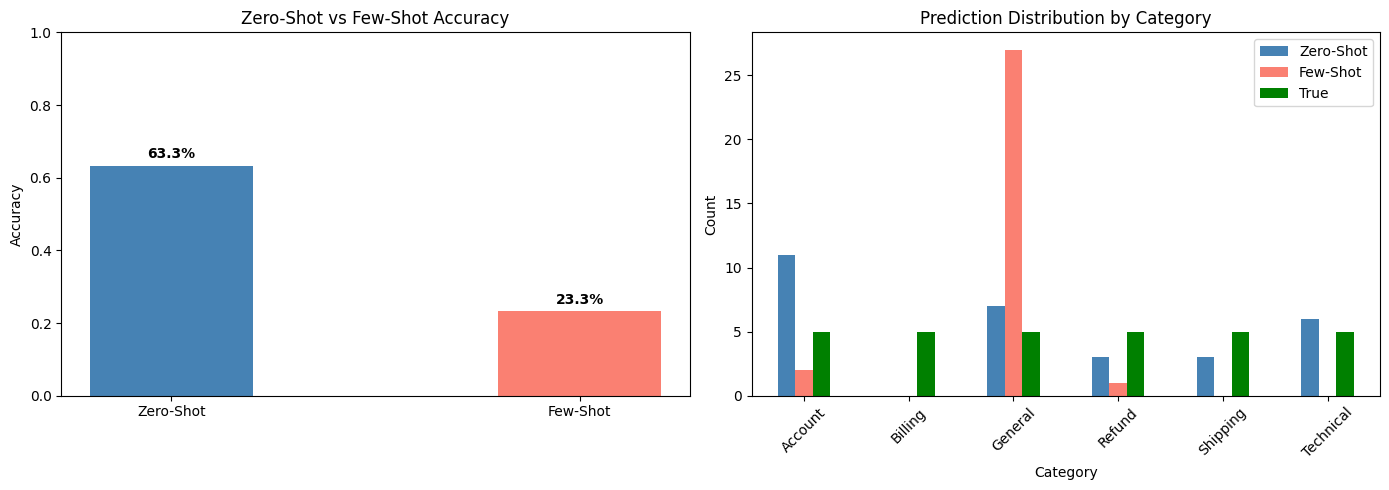

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison bar chart
approaches = ["Zero-Shot", "Few-Shot"]
accuracies = [zero_shot_acc, few_shot_acc]
colors = ["steelblue", "salmon"]

axes[0].bar(approaches, accuracies, color=colors, width=0.4)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Zero-Shot vs Few-Shot Accuracy")
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.02, f"{v*100:.1f}%", ha="center", fontweight="bold")

# Prediction distribution
pred_counts = pd.DataFrame({
    "Zero-Shot": df["zero_shot_pred"].value_counts(),
    "Few-Shot": df["few_shot_pred"].value_counts(),
    "True": df["true_label"].value_counts()
}).fillna(0)

pred_counts.plot(kind="bar", ax=axes[1], color=["steelblue", "salmon", "green"])
axes[1].set_title("Prediction Distribution by Category")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.tight_layout()
plt.savefig("comparison_plot.png")
plt.show()

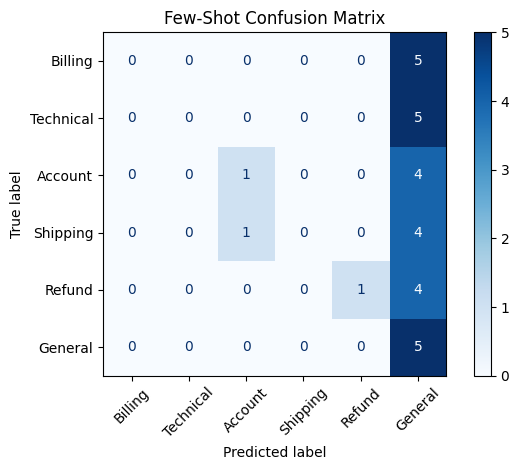

In [16]:
# Confusion matrix for few-shot
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(df["true_label"], df["few_shot_pred"], labels=CATEGORIES)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CATEGORIES)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Few-Shot Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

## 12. Download Outputs

In [17]:
from google.colab import files
files.download("comparison_plot.png")
files.download("confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Final Summary / Insights

### Performance Comparison
| Approach | Accuracy |
|----------|----------|
| Zero-Shot | 0.6333 (63.3%) |
| Few-Shot | 0.2333 (23.3%) |

### Key Observations
- **Zero-shot outperformed few-shot by 40%** — an unexpected but insightful result
- The prediction distribution chart reveals why: few-shot caused the model to over-generalize to the "General" category, classifying ~27 out of 30 tickets as "General" regardless of content — a known failure mode of small models with in-context learning
- **Top-3 accuracy was 100%** for the 10 evaluated tickets — the correct label appeared in the top-3 tags for every single ticket, showing that even when the top-1 prediction is wrong, the model has useful signal
- Zero-shot produced a more balanced prediction distribution, correctly identifying Account and Technical categories most frequently
- **Conclusion:** For small models like flan-t5-base, zero-shot prompting is more reliable than few-shot; few-shot learning requires larger models (Llama 3, Mistral, GPT-4) to work effectively

### Limitations
- flan-t5-base is too small for reliable few-shot learning — a larger LLM would reverse this result
- Synthetic dataset — real tickets are noisier and often multi-category
- Top-3 scoring is heuristic — logits-based scoring would be more principled